<img src="../Decorative-Elements/Section-02/ADL-S02-Image-07.png">

<p style="display: flex; justify-content: space-between;">
  <a href="../02-Understanding-Rebound/04-Orbital-Path.ipynb" target="_blank">Previous</a>
  <a href="../03-Solar-System/01-Simulation-of-Sun-and-Earth.ipynb" target="_blank">Next</a>
</p>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from matplotlib.patches import Polygon
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

<img src="../Decorative-Elements/Section-02/ADL-S02-Image-07-a.png">

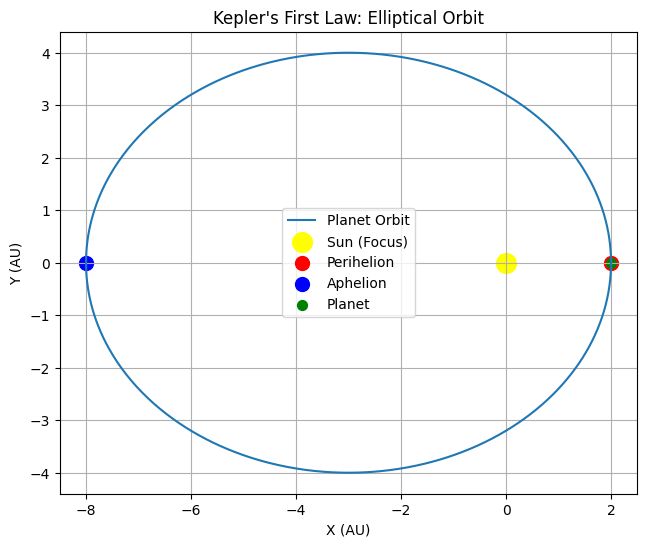

In [2]:
# Step 1: Define orbital parameters
a = 5          # Semi-major axis
e = 0.6        # Eccentricity (0 < e < 1)

# Step 2: Compute polar coordinates for the ellipse
theta = np.linspace(0, 2*np.pi, 1000)  # Angle range
r = a * (1 - e**2) / (1 + e * np.cos(theta))  # Polar equation

# Step 3: Convert polar to Cartesian coordinates
x = r * np.cos(theta)
y = r * np.sin(theta)

# Step 4: Identify perihelion and aphelion
perihelion = a * (1 - e)   # Closest distance
aphelion = a * (1 + e)     # Farthest distance

# Coordinates for key points
peri_x, peri_y = perihelion, 0
aphe_x, aphe_y = -aphelion, 0

# Step 5: Plot the orbit
plt.figure(figsize=(8,6))
plt.plot(x, y, label='Planet Orbit')         # Ellipse
plt.scatter(0, 0, color='yellow', s=200, label='Sun (Focus)')  # Sun
plt.scatter(peri_x, peri_y, color='red', s=100, label='Perihelion')
plt.scatter(aphe_x, aphe_y, color='blue', s=100, label='Aphelion')
plt.scatter(peri_x, peri_y, color='green', s=50, label='Planet')  # Planet at perihelion

# Step 6: Customize plot
plt.gca().set_aspect('equal')  # Keep the ellipse proportion correct
plt.title("Kepler's First Law: Elliptical Orbit")
plt.xlabel("X (AU)")
plt.ylabel("Y (AU)")
plt.legend()
plt.grid(True)
plt.show()

# Sun (yellow) → at the focus, origin (0,0).
# Orbit (black curve) → full elliptical orbit.
# Perihelion (red) → closest point to the Sun.
# Aphelion (blue) → farthest point from the Sun.
# Planet (green) → currently placed at perihelion for illustration.

<img src="../Decorative-Elements/Section-02/ADL-S02-Image-07-b.png">

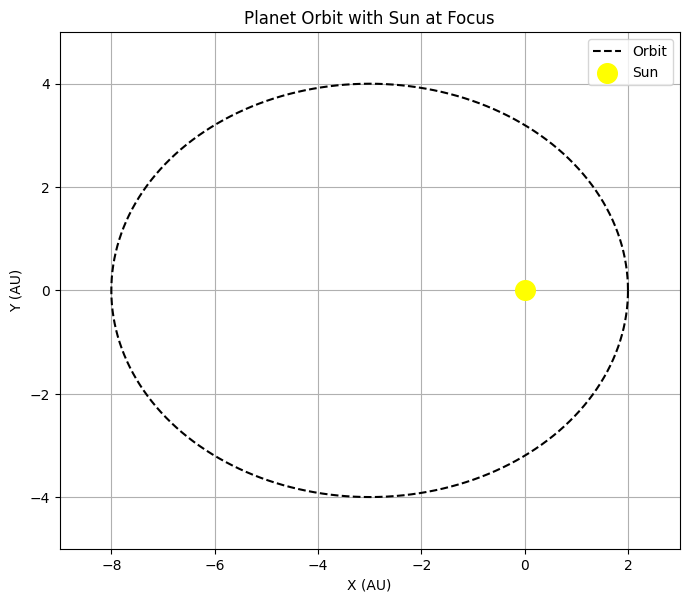

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Orbital parameters
a = 5
e = 0.6
b = a * np.sqrt(1 - e**2)  # semi-minor axis

# Full ellipse
theta = np.linspace(0, 2*np.pi, 1000)
x = a * np.cos(theta) - a*e  # shift to put Sun at origin
y = b * np.sin(theta)

# Determine axis limits based on orbit extents
x_min, x_max = x.min() - 1, x.max() + 1
y_min, y_max = y.min() - 1, y.max() + 1

plt.figure(figsize=(8,8))
plt.plot(x, y, 'k--', label='Orbit')

# Sun at origin
plt.scatter(0, 0, color='yellow', s=200, label='Sun', zorder=5)

plt.gca().set_aspect('equal')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.title("Planet Orbit with Sun at Focus")
plt.xlabel("X (AU)")
plt.ylabel("Y (AU)")
plt.legend()
plt.grid(True)
plt.show()

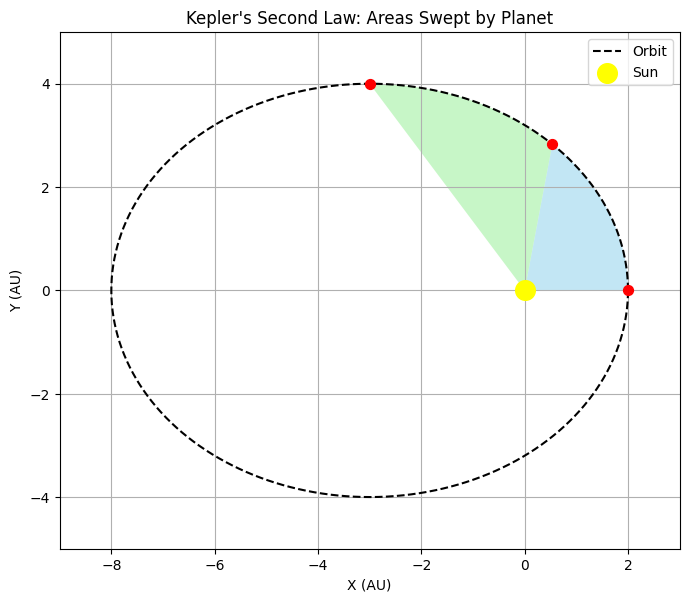

In [4]:
# Orbital parameters
a = 5
e = 0.6
b = a * np.sqrt(1 - e**2)  # semi-minor axis

# Full ellipse
theta = np.linspace(0, 2*np.pi, 1000)
x = a * np.cos(theta) - a*e  # shift to put Sun at origin
y = b * np.sin(theta)

# Define two consecutive sections along the orbit
theta_sections = [0, np.pi/4, np.pi/2]  # start, first section end, second section end
colors = ['skyblue', 'lightgreen']

plt.figure(figsize=(8,8))
plt.plot(x, y, 'k--', label='Orbit')

# Sun at origin
plt.scatter(0, 0, color='yellow', s=200, label='Sun', zorder=5)

# Draw two curved sections along the orbit
for i in range(len(theta_sections)-1):
    theta_sec = np.linspace(theta_sections[i], theta_sections[i+1], 100)
    x_sec = a * np.cos(theta_sec) - a*e
    y_sec = b * np.sin(theta_sec)
    
    # To make it a sector, include Sun at origin in polygon
    x_poly = np.concatenate(([0], x_sec))
    y_poly = np.concatenate(([0], y_sec))
    
    polygon = Polygon(np.column_stack((x_poly, y_poly)),
                      facecolor=colors[i], alpha=0.5, edgecolor='none', zorder=0)
    plt.gca().add_patch(polygon)

# Plot planet positions at section endpoints
for t in theta_sections:
    x_p = a * np.cos(t) - a*e
    y_p = b * np.sin(t)
    plt.scatter(x_p, y_p, color='red', s=50, zorder=5)

plt.gca().set_aspect('equal')

# Axis limits based on orbit extents
plt.xlim(x.min()-1, x.max()+1)
plt.ylim(y.min()-1, y.max()+1)

plt.title("Kepler's Second Law: Areas Swept by Planet")
plt.xlabel("X (AU)")
plt.ylabel("Y (AU)")
plt.legend()
plt.grid(True)
plt.show()

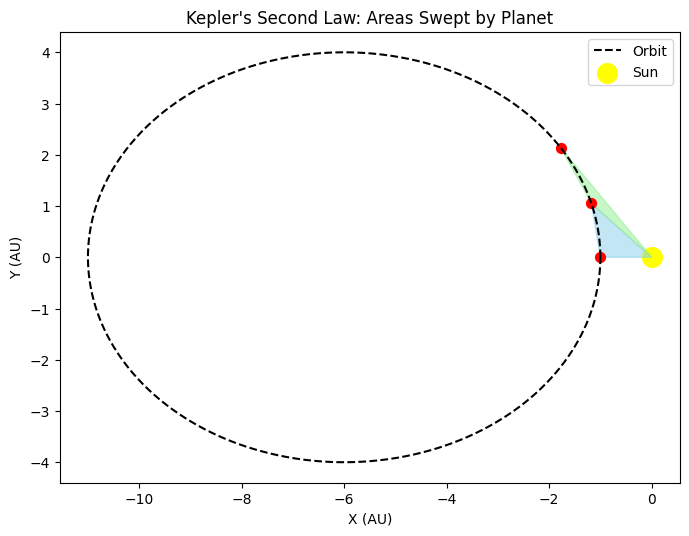

In [5]:
# Orbital parameters
a = 5
e = 0.6

# Function to convert polar to Cartesian (Sun at focus)
def polar_to_cartesian(a, e, theta):
    r = a*(1 - e**2) / (1 + e*np.cos(theta))
    x = r*np.cos(theta) - a*e  # Sun at origin
    y = r*np.sin(theta)
    return x, y

# Planet positions at three consecutive time intervals
theta_points = [0, np.pi/6, np.pi/3]
planet_positions = [polar_to_cartesian(a, e, t) for t in theta_points]

# Plot orbit
theta_vals = np.linspace(0, 2*np.pi, 1000)
x_vals, y_vals = polar_to_cartesian(a, e, theta_vals)
plt.figure(figsize=(8,8))
plt.plot(x_vals, y_vals, 'k--', label='Orbit')

# Plot Sun
plt.scatter(0,0,color='yellow', s=200, label='Sun')

# Draw areas swept in consecutive intervals
colors = ['skyblue', 'lightgreen']
for i in range(len(planet_positions)-1):
    x_sector = [0, planet_positions[i][0], planet_positions[i+1][0]]
    y_sector = [0, planet_positions[i][1], planet_positions[i+1][1]]
    polygon = Polygon(np.column_stack((x_sector, y_sector)), color=colors[i], alpha=0.5)
    plt.gca().add_patch(polygon)

# Plot planet positions
for x_p, y_p in planet_positions:
    plt.scatter(x_p, y_p, color='red', s=50)

plt.gca().set_aspect('equal')
plt.title("Kepler's Second Law: Areas Swept by Planet")
plt.xlabel("X (AU)")
plt.ylabel("Y (AU)")
plt.legend()
plt.show()

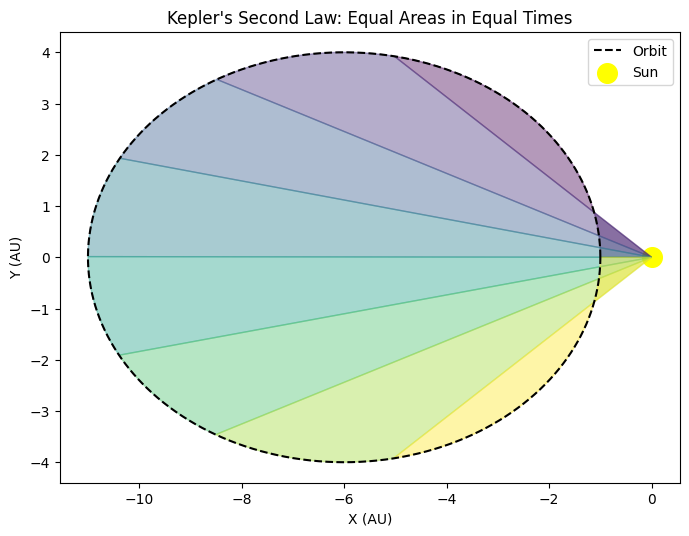

In [6]:
# Orbital parameters
a = 5       # semi-major axis
e = 0.6     # eccentricity
frames = 8  # number of equal-area sectors to show

# Function to convert polar to Cartesian (Sun at focus)
def polar_to_cartesian(a, e, theta):
    r = a*(1 - e**2) / (1 + e*np.cos(theta))
    x = r*np.cos(theta) - a*e  # shift so Sun at origin
    y = r*np.sin(theta)
    return x, y

# Compute angles for equal-area approximation (simplified)
theta_vals = np.linspace(0, 2*np.pi, 2000)
x_vals, y_vals = polar_to_cartesian(a, e, theta_vals)

# Approximate equal-area sectors using cumulative area
# Area ∝ 0.5 * r^2 * dtheta, simple numeric integration
r_vals = a*(1 - e**2)/(1 + e*np.cos(theta_vals))
dtheta = theta_vals[1] - theta_vals[0]
area_cum = np.cumsum(0.5 * r_vals**2 * dtheta)
total_area = area_cum[-1]
sector_area = total_area / frames

# Determine theta values for each sector
sector_theta = [0]
for i in range(1, frames):
    idx = np.argmin(np.abs(area_cum - i*sector_area))
    sector_theta.append(theta_vals[idx])
sector_theta.append(2*np.pi)

# Plot ellipse
plt.figure(figsize=(8,8))
plt.plot(x_vals, y_vals, 'k--', label='Orbit')

# Plot Sun
plt.scatter(0,0,color='yellow', s=200, label='Sun')

# Draw sectors
colors = plt.cm.viridis(np.linspace(0,1,frames))
for i in range(frames):
    t1, t2 = sector_theta[i], sector_theta[i+1]
    x_sector, y_sector = polar_to_cartesian(a, e, np.linspace(t1,t2,50))
    polygon = Polygon(np.column_stack(([0]+list(x_sector), [0]+list(y_sector))),
                      color=colors[i], alpha=0.4)
    plt.gca().add_patch(polygon)

plt.gca().set_aspect('equal')
plt.title("Kepler's Second Law: Equal Areas in Equal Times")
plt.xlabel("X (AU)")
plt.ylabel("Y (AU)")
plt.legend()
plt.show()

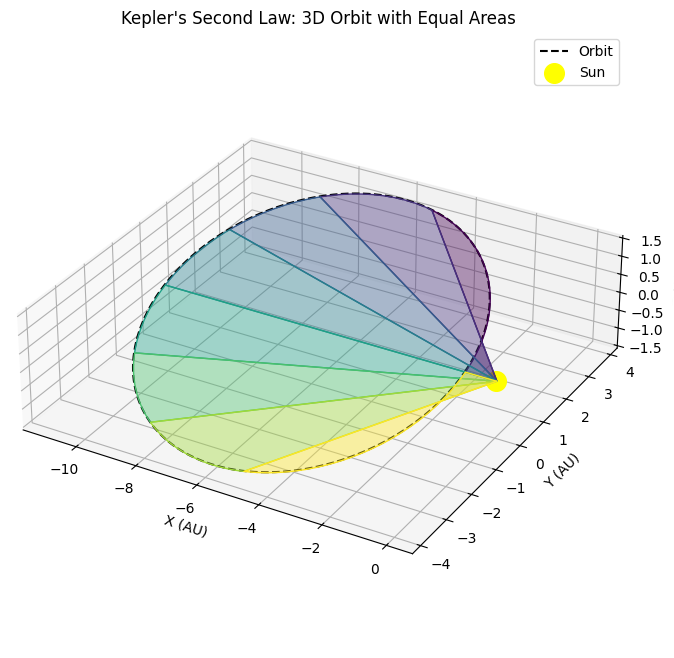

In [7]:
# Orbital parameters
a = 5
e = 0.6
frames = 8  # Number of sectors
tilt = np.radians(20)  # tilt the orbit for 3D view

# Function: polar to 3D Cartesian with Sun at origin and tilt
def polar_to_cartesian_3d(a, e, theta, tilt=0):
    r = a*(1 - e**2) / (1 + e*np.cos(theta))
    x = r*np.cos(theta) - a*e
    y = r*np.sin(theta) * np.cos(tilt)
    z = r*np.sin(theta) * np.sin(tilt)
    return x, y, z

# Orbit points
theta_vals = np.linspace(0, 2*np.pi, 2000)
x_vals, y_vals, z_vals = polar_to_cartesian_3d(a, e, theta_vals, tilt)

# Approximate equal-area sectors
r_vals = a*(1 - e**2)/(1 + e*np.cos(theta_vals))
dtheta = theta_vals[1] - theta_vals[0]
area_cum = np.cumsum(0.5 * r_vals**2 * dtheta)
total_area = area_cum[-1]
sector_area = total_area / frames

# Find theta values for each sector
sector_theta = [0]
for i in range(1, frames):
    idx = np.argmin(np.abs(area_cum - i*sector_area))
    sector_theta.append(theta_vals[idx])
sector_theta.append(2*np.pi)

# Create 3D plot
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# Plot orbit
ax.plot(x_vals, y_vals, z_vals, 'k--', label='Orbit')

# Plot Sun
ax.scatter(0,0,0,color='yellow', s=200, label='Sun')

# Draw equal-area sectors as 3D polygons
colors = plt.cm.viridis(np.linspace(0,1,frames))
for i in range(frames):
    t1, t2 = sector_theta[i], sector_theta[i+1]
    x_sec, y_sec, z_sec = polar_to_cartesian_3d(a, e, np.linspace(t1,t2,50), tilt)
    verts = np.column_stack(([0]+list(x_sec), [0]+list(y_sec), [0]+list(z_sec)))
    poly = Poly3DCollection([verts], color=colors[i], alpha=0.4)
    ax.add_collection3d(poly)

# Set aspect and labels
ax.set_box_aspect([1,1,0.3])
ax.set_title("Kepler's Second Law: 3D Orbit with Equal Areas")
ax.set_xlabel("X (AU)")
ax.set_ylabel("Y (AU)")
ax.set_zlabel("Z (AU)")
ax.legend()
plt.show()

In [8]:
# Orbital parameters
a = 5           # semi-major axis
e = 0.6         # eccentricity
frames_count = 8 # number of equal-area segments

# Compute polar coordinates for the ellipse
theta_full = np.linspace(0, 2*np.pi, 500)
r_full = a * (1 - e**2) / (1 + e * np.cos(theta_full))

# Shift the ellipse so that the Sun is at origin (focus)
f = a * e
x_full = r_full * np.cos(theta_full) - f
y_full = r_full * np.sin(theta_full)
z_full = np.zeros_like(x_full)

# Compute cumulative area to divide into equal-area segments
dtheta = theta_full[1] - theta_full[0]
area_cum = np.cumsum(0.5 * r_full**2 * dtheta)
total_area = area_cum[-1]
segment_area = total_area / frames_count

# Find indices for 8 equal-area segments
segment_indices = [0]
for i in range(1, frames_count):
    idx = np.argmin(np.abs(area_cum - i*segment_area))
    segment_indices.append(idx)
segment_indices.append(len(theta_full)-1)

# Colors for segments
segment_colors = ["#636EFA","#EF553B","#00CC96","#AB63FA",
                  "#FFA15A","#19D3F3","#FF6692","#B6E880"]

# Create figure
fig = go.Figure()

# Full orbit (dashed black)
fig.add_trace(go.Scatter3d(
    x=x_full, y=y_full, z=z_full,
    mode='lines',
    line=dict(color='black', dash='dash'),
    name='Orbit'
))

# Sun at focus
fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers',
    marker=dict(size=10, color='yellow'),
    name='Sun'
))

# 8 equal-area segments (thin colored lines)
for i in range(frames_count):
    idx_start = segment_indices[i]
    idx_end = segment_indices[i+1]+1
    fig.add_trace(go.Scatter3d(
        x=np.concatenate(([0], x_full[idx_start:idx_end])),
        y=np.concatenate(([0], y_full[idx_start:idx_end])),
        z=np.zeros(idx_end - idx_start + 1),
        mode='lines',
        line=dict(color=segment_colors[i], width=2),
        name=f'Segment {i+1}'
    ))

# Initial planet position at first segment
planet_x = x_full[segment_indices[0]]
planet_y = y_full[segment_indices[0]]
planet_z = 0

planet_trace = go.Scatter3d(
    x=[planet_x], y=[planet_y], z=[planet_z],
    mode='markers',
    marker=dict(size=6, color='blue'),
    name='Planet'
)
fig.add_trace(planet_trace)

# Frames for slider animation
frames = []
for i in range(frames_count):
    x_pos = x_full[segment_indices[i]]
    y_pos = y_full[segment_indices[i]]
    frames.append(go.Frame(
        data=[go.Scatter3d(
            x=[x_pos], y=[y_pos], z=[0],
            mode='markers',
            marker=dict(size=6, color='blue')
        )],
        name=str(i)
    ))
fig.frames = frames

# Slider configuration
sliders = [dict(
    steps=[dict(method='animate',
                args=[[str(k)],
                      dict(mode='immediate',
                           frame=dict(duration=500, redraw=True),
                           transition=dict(duration=0))],
                label=f'Segment {k+1}') for k in range(frames_count)],
    active=0,
    transition=dict(duration=0),
    x=0, y=0,
    currentvalue=dict(prefix="Planet at: "),
    len=1.0
)]

# Layout
fig.update_layout(
    title="Kepler's Second Law: Planet Motion in 8 Equal-Area Segments",
    scene=dict(
        xaxis=dict(title='X (AU)'),
        yaxis=dict(title='Y (AU)'),
        zaxis=dict(title='Z (AU)'),
        aspectratio=dict(x=1, y=1, z=0.3)
    ),
    updatemenus=[dict(type='buttons',
                      buttons=[dict(label='Play',
                                    method='animate',
                                    args=[None,
                                          dict(frame=dict(duration=500, redraw=True),
                                               fromcurrent=True,
                                               mode='immediate')])])],
    sliders=sliders
)

fig.show()

# Output is not visible in github webpage, refer to Folder/Output-Plotly

<img src="../Decorative-Elements/Section-02/ADL-S02-Image-07-c.png">

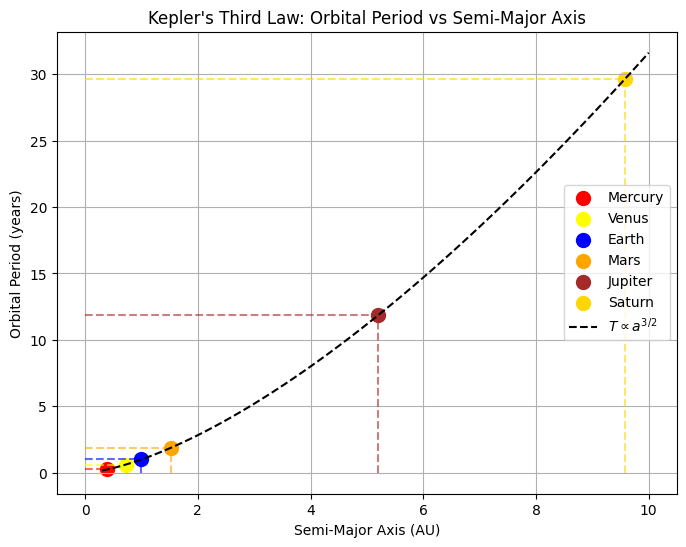

In [9]:
# Planetary data
planets = {
    "Mercury": 0.39,
    "Venus": 0.72,
    "Earth": 1.0,
    "Mars": 1.52,
    "Jupiter": 5.2,
    "Saturn": 9.58
}

a = np.array(list(planets.values()))        # semi-major axes (AU)
T = a**(3/2)                                 # orbital period (years) using Kepler's Third Law

# Assign distinct colors to planets
colors = ["red", "yellow", "blue", "orange", "brown", "gold"]

# Plot planets with colored points and vertical tracing lines
plt.figure(figsize=(8,6))
for i, (name, x_val, y_val) in enumerate(zip(planets.keys(), a, T)):
    # Draw vertical line from x-axis to planet point
    plt.plot([x_val, x_val], [0, y_val], color=colors[i], linestyle='--', alpha=0.6)
    plt.plot([0, x_val], [y_val, y_val], color=colors[i], linestyle='--', alpha=0.6)
    # Draw planet point
    plt.scatter(x_val, y_val, color=colors[i], s=100, label=name)

# Plot theoretical curve
a_curve = np.linspace(0.3, 10, 100)
T_curve = a_curve**(3/2)
plt.plot(a_curve, T_curve, 'k--', label=r'$T \propto a^{3/2}$')

plt.title("Kepler's Third Law: Orbital Period vs Semi-Major Axis")
plt.xlabel("Semi-Major Axis (AU)")
plt.ylabel("Orbital Period (years)")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# Planetary data
planets = {
    "Mercury": 0.39,
    "Venus": 0.72,
    "Earth": 1.0,
    "Mars": 1.52,
    "Jupiter": 5.2,
    "Saturn": 9.58
}

a_vals = np.array(list(planets.values()))
names = list(planets.keys())
T_vals = a_vals**(3/2)  # Orbital periods

# Planet colors
colors = ["gray", "orange", "blue", "red", "brown", "gold"]

# Animation parameters
frames_count = 200

# Compute positions for all frames
theta_frames = [2*np.pi * np.arange(frames_count) / (frames_count * T) for T in T_vals]
x_frames = [a * np.cos(theta) for a, theta in zip(a_vals, theta_frames)]
y_frames = [a * np.sin(theta) for a, theta in zip(a_vals, theta_frames)]
z_frames = [np.zeros_like(x) for x in x_frames]

# Create Plotly figure
fig = go.Figure()

# Initial Sun trace (included in every frame)
sun_trace = go.Scatter3d(x=[0], y=[0], z=[0], mode='markers',
                         marker=dict(size=10, color='yellow'),
                         name='Sun')
fig.add_trace(sun_trace)

# Initial planet traces
for i, name in enumerate(names):
    fig.add_trace(go.Scatter3d(
        x=[x_frames[i][0]], y=[y_frames[i][0]], z=[z_frames[i][0]],
        mode='markers+lines',
        line=dict(dash='dash', color=colors[i]),
        marker=dict(size=6, color=colors[i]),
        name=name
    ))

# Create frames
frames = []
for f in range(frames_count):
    frame_data = []
    # Add Sun in each frame
    frame_data.append(go.Scatter3d(
        x=[0], y=[0], z=[0],
        mode='markers',
        marker=dict(size=10, color='yellow'),
        name='Sun'
    ))
    # Add planets in frame
    for i in range(len(names)):
        frame_data.append(go.Scatter3d(
            x=[x_frames[i][f]], y=[y_frames[i][f]], z=[z_frames[i][f]],
            mode='markers+lines',
            line=dict(dash='dash', color=colors[i]),
            marker=dict(size=6, color=colors[i]),
            name=names[i]
        ))
    frames.append(go.Frame(data=frame_data, name=str(f)))

fig.frames = frames

# Layout and play button
fig.update_layout(
    title="Kepler's Third Law: 3D Planetary Orbits",
    scene=dict(
        xaxis=dict(title='X (AU)'),
        yaxis=dict(title='Y (AU)'),
        zaxis=dict(title='Z (AU)'),
        aspectratio=dict(x=1, y=1, z=0.3)
    ),
    updatemenus=[dict(
        type="buttons",
        buttons=[dict(label="Play",
                      method="animate",
                      args=[None, dict(frame=dict(duration=50, redraw=True),
                                       fromcurrent=True, mode='immediate')])]
    )]
)

fig.show()

# Output is not visible in github webpage, refer to Folder/Output-Plotly

<p style="display: flex; justify-content: space-between;">
  <a href="../02-Understanding-Rebound/04-Orbital-Path.ipynb" target="_blank">Previous</a>
  <a href="../03-Solar-System/01-Simulation-of-Sun-and-Earth.ipynb" target="_blank">Next</a>
</p>

<img src="../Decorative-Elements/Section-Footer-Animated/Section-02-05.gif">